In [1]:
import sys
import os

sys.path.insert(0, '/home/ubuntu/Bakalarka/QSPRpred/qsprpred/extra/gpu/models')

import torch

from qsprpred.data import QSPRDataset, RandomSplit
from qsprpred.data.descriptors.fingerprints import MorganFP
import pandas as pd
from qsprpred.data.descriptors.sets import RDKitDescs
from MolEval import MolEmb 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd
from sklearn.feature_selection import VarianceThreshold
from qsprpred.data.descriptors.sets import RDKitDescs

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


In [2]:
X1 = pd.read_csv("mod_data/X1.1", index_col="QSPRID")
X2 = pd.read_csv("mod_data/X2.1", index_col="QSPRID")
X3 = pd.read_csv("mod_data/X3.1", index_col="QSPRID")
y1 = pd.read_csv("mod_data/y1.1", index_col="QSPRID")
y2 = pd.read_csv("mod_data/y2.1", index_col="QSPRID")
y3 = pd.read_csv("mod_data/y3.1", index_col="QSPRID")


In [3]:
X1.columns = X1.columns.astype(str)
X2.columns = X2.columns.astype(str)
X3.columns = X3.columns.astype(str)

imp_mean = SimpleImputer(missing_values=pd.NA, strategy='mean')
X1 = imp_mean.fit_transform(X1)
X2 = imp_mean.transform(X2)
X3 = imp_mean.transform(X3)
scaler = StandardScaler()
scaler.fit(X1)
X1 = scaler.transform(X1)
X2 = scaler.transform(X2)
X3 = scaler.transform(X3)

In [4]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95)
pca.fit(X1)


PCA(n_components=0.95)

In [5]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Např. najít počet komponent, které vysvětlí 95 % rozptylu
n_components = np.argmax(cum_var >= 0.95) + 1
n_components

1854

In [6]:
pca = PCA(n_components=n_components)
X1 = pca.fit_transform(X1)
X2 = pca.transform(X2)
X3 = pca.transform(X3)

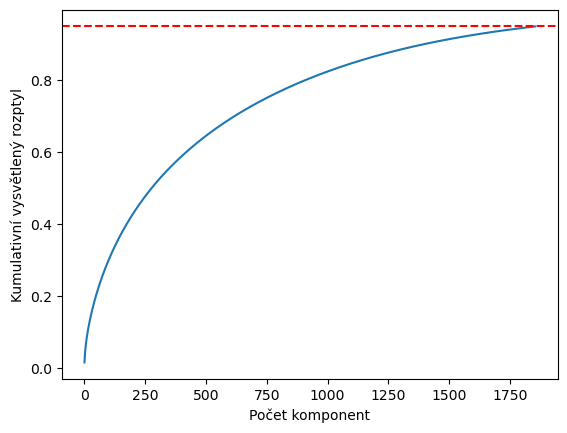

In [7]:
import matplotlib.pyplot as plt

plt.plot(range(1, len(cum_var)+1), cum_var)
plt.axhline(y=0.95, color='r', linestyle='--')
plt.xlabel('Počet komponent')
plt.ylabel('Kumulativní vysvětlený rozptyl')
plt.show()

In [8]:
n_components

1854

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=8)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(n_neighbors=8)

In [10]:
pred = knn.predict(X2)

In [11]:
from sklearn.metrics import matthews_corrcoef, accuracy_score, f1_score

print("Acc:", accuracy_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.6661346951803383
Mcc: 0.29512157492023394


In [12]:
from sklearn.model_selection import ParameterGrid
from tqdm import tqdm
import pandas as pd
param_grid = ParameterGrid({
    'n_neighbors': [1, 3, 5, 7, 9, 11, 15, 21, 31],  # různé hodnoty K
    'weights': ['uniform', 'distance'],             # vážení sousedů
    'metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],  # různé metriky vzdálenosti
    'p': [1, 2],                                     # pro minkowski: p=1 (Manhattan), p=2 (Eukleidovská)
    'leaf_size': [10, 20, 30, 50, 100],              # ovlivňuje rychlost vyhledávání
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']  # různé algoritmy pro hledání sousedů
})

val_mcc = []
val_f1 = []
val_acc = []
for param in tqdm(param_grid, total=len(param_grid)):
    knn = KNeighborsClassifier(**param)
    knn.fit(X1, y1["Y"])
    pred = knn.predict(X2)
    val_mcc.append(matthews_corrcoef(pred, y2["Y"]))
    val_f1.append(f1_score(pred, y2["Y"]))
    val_acc.append(accuracy_score(pred, y2["Y"]))
    print("Params:", param, "\nMCC:", matthews_corrcoef(pred, y2["Y"]))



  0%|                                            | 1/2880 [00:02<2:13:04,  2.77s/it]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'uniform'} 
MCC: 0.28328880000800977


  0%|                                            | 2/2880 [00:05<2:10:00,  2.71s/it]

Params: {'algorithm': 'auto', 'leaf_size': 10, 'metric': 'euclidean', 'n_neighbors': 1, 'p': 1, 'weights': 'distance'} 
MCC: 0.28328880000800977


  0%|                                            | 3/2880 [00:08<2:09:13,  2.70s/it]

...

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 1, 'weights': 'distance'} 
MCC: 0.1446202801705488


100%|███████████████████████████████████████▉| 2879/2880 [23:51:01<00:03,  3.42s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'uniform'} 
MCC: 0.20592066437466588


100%|████████████████████████████████████████| 2880/2880 [23:51:03<00:00, 29.81s/it]

Params: {'algorithm': 'brute', 'leaf_size': 100, 'metric': 'minkowski', 'n_neighbors': 31, 'p': 2, 'weights': 'distance'} 
MCC: 0.22809324184027602


In [13]:
knn_res = pd.DataFrame(param_grid)

In [14]:
knn_res["mcc"] = val_mcc
knn_res["f1"] = val_f1
knn_res["acc"] = val_acc

In [15]:
knn_res.sort_values(by=["mcc", "f1", "acc"], ascending=False, inplace=True)

In [16]:
knn_res.to_csv("res/knn_without_smote_res_val_1.1.csv")

In [22]:
knn_res

,algorithm,leaf_size,metric,n_neighbors,p,weights,mcc,f1,acc
72,auto,10,chebyshev,1,1,uniform,0.332383,0.732162,0.678902
73,auto,10,chebyshev,1,1,distance,0.332383,0.732162,0.678902
74,auto,10,chebyshev,1,2,uniform,0.332383,0.732162,0.678902
75,auto,10,chebyshev,1,2,distance,0.332383,0.732162,0.678902
216,auto,20,chebyshev,1,1,uniform,0.332383,0.732162,0.678902
...,...,...,...,...,...,...,...,...,...
2662,brute,50,manhattan,31,2,uniform,0.135279,0.744090,0.606128
2732,brute,50,minkowski,31,1,uniform,0.135279,0.744090,0.606128
2804,brute,100,manhattan,31,1,uniform,0.135279,0.744090,0.606128
2806,brute,100,manhattan,31,2,uniform,0.135279,0.744090,0.606128


In [17]:
import numpy as np
best_params = param_grid[np.argmax(val_mcc)]

In [18]:
best_params

{'weights': 'uniform',
 'p': 1,
 'n_neighbors': 1,
 'metric': 'chebyshev',
 'leaf_size': 10,
 'algorithm': 'auto'}

In [19]:
knn = KNeighborsClassifier(**best_params)
knn.fit(X1, y1)

/home/ubuntu/miniconda3/envs/bakalarka_env/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


KNeighborsClassifier(leaf_size=10, metric='chebyshev', n_neighbors=1, p=1)

In [20]:
pred = knn.predict(X2)

print("Acc:", accuracy_score(pred, y2))
print("F1:", f1_score(pred, y2))
print("Mcc:", matthews_corrcoef(pred, y2))

Acc: 0.6789020108522184
F1: 0.7321618743343983
Mcc: 0.33238277487111556


In [21]:
pred_test = knn.predict(X3)

print("Acc:", accuracy_score(pred_test, y3))
print("F1:", f1_score(pred_test, y3))
print("Mcc:", matthews_corrcoef(pred_test, y3))

Acc: 0.6531653165316532
F1: 0.7209077740222115
Mcc: 0.26290510024961544
